In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**DSO**:
ce modele est un systeme de recommandation et de predection il analyse le passe pour comprendre qui reussit regroupe les profiles similaires et predit avec une certitude quasi-totale les resultats future
**BO**:
Système intelligent qui analyse les données passées, regroupe des profils similaires et prédit les résultats futurs avec une forte précision.

In [2]:
# ── Configuration Kaggle avec token KGAT (nouvelle API) ───────────────────
import os

# Colle ton token ici
KAGGLE_TOKEN = "KGAT_0c9f6b5d34c44d217da5d5b6671a0725"

os.environ["KAGGLE_API_TOKEN"] = KAGGLE_TOKEN

# Installation de la dernière version de kaggle
!pip install kaggle -q --upgrade

print("✅ Token configuré !")

✅ Token configuré !



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ── Téléchargement direct du dataset Codeforces ───────────────────────────
!kaggle datasets download -d abukanabek/codeforces-competitive-history-dataset --unzip

# Vérification des fichiers
import os
print("\n📁 Fichiers disponibles :")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        size = os.path.getsize(f) / 1024
        print(f"   ✔ {f}  ({size:.0f} KB)")

Dataset URL: https://www.kaggle.com/datasets/abukanabek/codeforces-competitive-history-dataset
License(s): CC-BY-SA-4.0


📁 Fichiers disponibles :
   ✔ contests.csv  (212 KB)
   ✔ rating_changes.csv  (12315 KB)
   ✔ users.csv  (379 KB)



  0%|          | 0.00/3.29M [00:00<?, ?B/s]
 30%|███       | 1.00M/3.29M [00:00<00:01, 1.95MB/s]
 61%|██████    | 2.00M/3.29M [00:00<00:00, 2.32MB/s]
 91%|█████████▏| 3.00M/3.29M [00:01<00:00, 2.87MB/s]
100%|██████████| 3.29M/3.29M [00:01<00:00, 2.46MB/s]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.decomposition    import PCA
from sklearn.cluster          import KMeans, DBSCAN
from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.tree             import DecisionTreeClassifier, plot_tree
from sklearn.linear_model     import LinearRegression, LogisticRegression
from sklearn.metrics          import (accuracy_score, confusion_matrix,
                                       classification_report, roc_curve,
                                       auc, f1_score, mean_squared_error, r2_score)

warnings.filterwarnings('ignore')
sns.set(style='whitegrid', context='talk', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("✅ Imports OK")

✅ Imports OK


In [6]:
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print(f"CSV trouvés : {csv_files}")

# Load all available CSVs into separate dataframes
all_dfs = {}
for f in csv_files:
    df_name = f.replace('.csv', '')
    all_dfs[df_name] = pd.read_csv(f)
    print(f"✅ '{f}' chargé : {all_dfs[df_name].shape[0]:,} lignes × {all_dfs[df_name].shape[1]} colonnes")

# Prioritize 'rating_changes.csv' as the main dataframe for target variable
if 'rating_changes' in all_dfs:
    df = all_dfs['rating_changes'].copy()
    main_df_name = 'rating_changes'
    print(f"\n→ '{main_df_name}.csv' sélectionné comme dataframe principal.")
else:
    # Fallback if rating_changes.csv is not present
    main_df_name = 'contests' if 'contests' in all_dfs else list(all_dfs.keys())[0]
    df = all_dfs[main_df_name].copy()
    print(f"\n→ '{main_df_name}.csv' sélectionné comme dataframe principal (fallback).")

# Merge with 'users.csv' if available and relevant
if 'users' in all_dfs and 'handle' in df.columns and 'handle' in all_dfs['users'].columns:
    df = df.merge(all_dfs['users'], on='handle', how='left', suffixes=('', '_usr'))
    print(f"✅ Fusion avec users.csv sur 'handle' → {df.shape[0]:,} lignes")

# Merge with 'contests.csv' if available and relevant
if 'contests' in all_dfs and 'contestId' in df.columns and 'contestId' in all_dfs['contests'].columns:
    df = df.merge(all_dfs['contests'], on='contestId', how='left', suffixes=('', '_cnt'))
    print(f"✅ Fusion avec contests.csv sur 'contestId' → {df.shape[0]:,} lignes")


print("\n--- Aperçu du DataFrame après chargement et fusion ---")
display(df.head())

CSV trouvés : ['contests.csv', 'rating_changes.csv', 'users.csv']
✅ 'contests.csv' chargé : 2,074 lignes × 10 colonnes
✅ 'rating_changes.csv' chargé : 306,886 lignes × 7 colonnes
✅ 'users.csv' chargé : 5,007 lignes × 12 colonnes

→ 'rating_changes.csv' sélectionné comme dataframe principal.
✅ Fusion avec users.csv sur 'handle' → 306,886 lignes
✅ Fusion avec contests.csv sur 'contestId' → 306,886 lignes

--- Aperçu du DataFrame après chargement et fusion ---


,Unnamed: 0,handle,contestId,oldRating,newRating,problems_solved,problems_solved_num,Unnamed: 0_usr,global_rank,rating,...,contribution,Unnamed: 0_cnt,name,type,phase,durationSeconds,startTimeSeconds,problems_in_contest,contestants_count,ratingUpdateTimeSeconds
0,0,Kevin114514,1110,0,1467,A|B,2.0,0,1,3814,...,107,1015,Codeforces Global Round 1,CF,FINISHED,7200,1549546500,A|B|C|D|E|F|G|H,6636.0,1.549554e+09
1,1,Kevin114514,1114,1467,1433,A,1.0,0,1,3814,...,107,1014,Codeforces Round 538 (Div. 2),CF,FINISHED,7200,1549807500,A|B|C|D|E|F,6671.0,1.549815e+09
2,2,Kevin114514,1181,1433,1377,A,1.0,0,1,3814,...,107,955,Codeforces Round 567 (Div. 2),CF,FINISHED,7200,1560677700,A|B|C|D|E1|E2,4669.0,1.560685e+09
3,3,Kevin114514,1200,1377,1397,A|C,2.0,0,1,3814,...,107,932,Codeforces Round 578 (Div. 2),CF,FINISHED,7200,1565526900,A|B|C|D|E|F,6913.0,1.565534e+09
4,4,Kevin114514,1262,1397,1283,NaN,NaN,0,1,3814,...,107,878,"Codeforces Round 602 (Div. 2, based on Technoc...",CF,FINISHED,7200,1574582700,A|B|C|D1|D2|E|F1|F2,2950.0,1.574590e+09


In [7]:
# ── Exploration détaillée ─────────────────────────────────────────────────
print("=" * 60)
print("INFORMATIONS GÉNÉRALES")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("STATISTIQUES DESCRIPTIVES")
print("=" * 60)
df.describe()

INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 306886 entries, 0 to 306885
Data columns (total 27 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               306886 non-null  int64  
 1   handle                   306886 non-null  str    
 2   contestId                306886 non-null  int64  
 3   oldRating                306886 non-null  int64  
 4   newRating                306886 non-null  int64  
 5   problems_solved          254319 non-null  str    
 6   problems_solved_num      254319 non-null  float64
 7   Unnamed: 0_usr           306886 non-null  int64  
 8   global_rank              306886 non-null  int64  
 9   rating                   306886 non-null  int64  
 10  maxRating                306886 non-null  int64  
 11  rank                     306886 non-null  str    
 12  maxRank                  306886 non-null  str    
 13  registrationTimeSeconds  306886 non-null  int64

,Unnamed: 0,contestId,oldRating,newRating,problems_solved_num,Unnamed: 0_usr,global_rank,rating,maxRating,registrationTimeSeconds,friendOfCount,contribution,Unnamed: 0_cnt,durationSeconds,startTimeSeconds,contestants_count,ratingUpdateTimeSeconds
count,306886.000000,306886.000000,306886.000000,306886.000000,254319.000000,306886.000000,306886.000000,306886.000000,306886.000000,3.068860e+05,306886.000000,306886.000000,306886.000000,306886.000000,3.068860e+05,306886.000000,3.068860e+05
mean,153442.500000,1820.865432,1667.526723,1698.970272,3.541391,2302.651998,2300.089799,1973.964462,2124.356474,1.609972e+09,417.419234,8.618937,344.943719,8124.445885,1.687088e+09,11168.089121,1.687096e+09
std,88590.501693,376.474833,485.030629,437.470318,1.183407,1450.228695,1447.969462,330.014136,363.048451,1.053846e+08,3058.088409,21.556046,354.971078,1305.695780,7.783540e+07,5114.615913,7.783561e+07
min,0.000000,1.000000,-52.000000,-52.000000,1.000000,0.000000,1.000000,1623.000000,1623.000000,1.264793e+09,0.000000,-126.000000,2.000000,7200.000000,1.266581e+09,0.000000,1.266588e+09
25%,76721.250000,1695.000000,1429.000000,1449.000000,3.000000,1022.000000,1018.000000,1726.000000,1864.000000,1.561603e+09,31.000000,0.000000,98.000000,7200.000000,1.655390e+09,8998.000000,1.655397e+09
50%,153442.500000,1941.000000,1681.000000,1693.000000,3.000000,2214.000000,2215.000000,1880.000000,2066.000000,1.636795e+09,80.000000,0.000000,231.000000,7200.000000,1.710168e+09,11705.000000,1.710176e+09
75%,230163.750000,2084.000000,1934.000000,1941.000000,4.000000,3525.000000,3517.000000,2132.000000,2282.000000,1.687862e+09,239.000000,5.000000,466.000000,9000.000000,1.742654e+09,14558.000000,1.742661e+09
max,306885.000000,2182.000000,4039.000000,4039.000000,18.000000,5006.000000,4983.000000,3814.000000,4039.000000,1.766504e+09,86318.000000,157.000000,2073.000000,18000.000000,1.767019e+09,21497.000000,1.767026e+09


In [8]:
# @title Default title text
print("Valeurs manquantes :")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing if len(missing) > 0 else "   → Aucune valeur manquante ✅")

Valeurs manquantes :
city                   118624
country                 53338
problems_solved         52567
problems_solved_num     52567
problems_in_contest        57
dtype: int64


In [13]:
df = df.copy()

# ── Suppression des doublons ──────────────────────────────────────────────
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Doublons supprimés : {before - len(df)}")

# ── Construction de la cible y AVANT de définir les features ─────────────
# ⚠️ IMPORTANT : la cible doit être définie AVANT pour éviter le leakage
if 'ratingChange' in df.columns:
    y = (df['ratingChange'] > 0).astype(int)
    target = 'ratingChange > 0'
elif 'newRating' in df.columns and 'oldRating' in df.columns:
    y = (df['newRating'] > df['oldRating']).astype(int)
    target = 'newRating > oldRating'
elif 'success' in df.columns:
    y = df['success'].astype(int)
    target = 'success'
else:
    c0 = df.select_dtypes(include=[np.number]).columns[0]
    y = (df[c0] > df[c0].median()).astype(int)
    target = f'{c0} > médiane'

print(f"✅ Cible : {target}")
print(f"✅ Distribution y : {y.value_counts().to_dict()}")

# ── ⚠️ CORRECTION OVERFITTING : Features sans leakage ────────────────────
# On exclut oldRating, newRating, ratingChange car ils permettent de
# calculer directement la cible → fuite d'information garantie
LEAKAGE_COLS = [
    'oldRating', 'newRating', 'ratingChange',
    'success', 'newRating_usr', 'oldRating_usr',
    'Unnamed: 0', 'Unnamed: 0_usr', 'Unnamed: 0_cnt',
    'handle', 'contestId', 'startTimeSeconds',
    'ratingUpdateTimeSeconds',   # timestamp lié au résultat
]

# Uniquement les features connues AVANT le résultat du contest
SAFE_FEATURES = [
    'problems_solved_num',   # nb problèmes résolus dans ce contest
    'rating',                # rating de l'utilisateur AVANT le contest
    'global_rank',           # classement global de l'utilisateur
    'contribution',          # contribution Codeforces de l'utilisateur
    'contestants_count',     # nb de participants au contest
    'durationSeconds',       # durée du contest
    'friendOfCount',         # popularité de l'utilisateur
    'registrationTimeSeconds', # ancienneté du compte
]

# Garder uniquement celles qui existent dans le dataframe
features_num = [f for f in SAFE_FEATURES if f in df.columns]
print(f"\n✅ Features numériques retenues : {features_num}")

# ── Colonnes catégorielles sûres ──────────────────────────────────────────
CAT_SAFE = ['country', 'city', 'organization', 'rank', 'maxRank',
            'type', 'phase']
cat_cols = [c for c in CAT_SAFE if c in df.columns]

# ── Remplissage NaN ───────────────────────────────────────────────────────
for c in features_num:
    if df[c].isnull().any():
        df[c].fillna(df[c].median(), inplace=True)
for c in cat_cols:
    if df[c].isnull().any():
        df[c].fillna('Unknown', inplace=True)

# ── Encodage des colonnes catégorielles ──────────────────────────────────
le = LabelEncoder()
encoded_cat_features = []
for c in cat_cols:
    col_enc = f'{c}_enc'
    df[col_enc] = le.fit_transform(df[c].astype(str))
    encoded_cat_features.append(col_enc)

print(f"✅ Features catégorielles encodées : {encoded_cat_features}")

# ── Features finales ──────────────────────────────────────────────────────
features = list(dict.fromkeys(features_num + encoded_cat_features))
X = df[features].copy()

# ── Standardisation ───────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✅ Features finales ({len(features)}) : {features}")
print(f"✅ Shape X : {X.shape}")
print(f"✅ Shape y : {y.shape}")

# ── Vérification anti-leakage ─────────────────────────────────────────────
leaked = [f for f in features if f in LEAKAGE_COLS]
if leaked:
    print(f"\n⚠️  ATTENTION : features leakées encore présentes → {leaked}")
else:
    print(f"\n✅ Aucun leakage détecté dans les features !")

Doublons supprimés : 0
✅ Cible : newRating > oldRating
✅ Distribution y : {1: 177906, 0: 128980}

✅ Features numériques retenues : ['problems_solved_num', 'rating', 'global_rank', 'contribution', 'contestants_count', 'durationSeconds', 'friendOfCount', 'registrationTimeSeconds']
✅ Features catégorielles encodées : ['country_enc', 'city_enc', 'rank_enc', 'maxRank_enc', 'type_enc', 'phase_enc']

✅ Features finales (14) : ['problems_solved_num', 'rating', 'global_rank', 'contribution', 'contestants_count', 'durationSeconds', 'friendOfCount', 'registrationTimeSeconds', 'country_enc', 'city_enc', 'rank_enc', 'maxRank_enc', 'type_enc', 'phase_enc']
✅ Shape X : (306886, 14)
✅ Shape y : (306886,)

✅ Aucun leakage détecté dans les features !


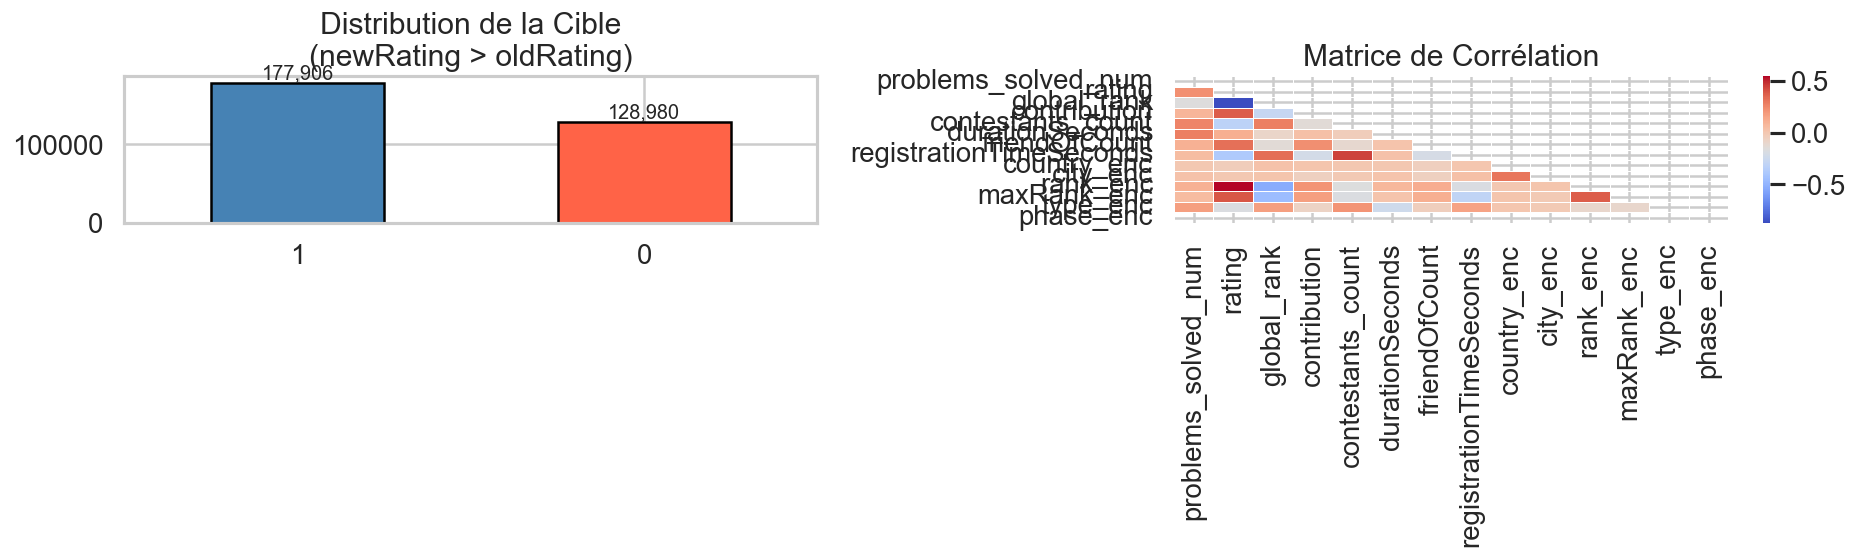

In [14]:
# ── Visualisation de la distribution + corrélations ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

y.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'],
                      edgecolor='black')
axes[0].set_title(f'Distribution de la Cible\n({target})')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=12)

corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', ax=axes[1],
            annot=(len(features) <= 10), fmt='.2f', linewidths=0.5)
axes[1].set_title('Matrice de Corrélation')

plt.tight_layout()
plt.savefig('00_data_overview.png')
plt.show()

In [12]:
# ── ACP – variance expliquée ──────────────────────────────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)
explained_var = pca_full.explained_variance_ratio_ * 100
cumulative    = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue', alpha=0.7)
axes[0].plot(range(1, len(explained_var)+1), cumulative, 'ro-', label='Cumulatif')
axes[0].axhline(90, color='green', ls='--', label='90%')
axes[0].set_xlabel('Composante')
axes[0].set_ylabel('Variance expliquée (%)')
axes[0].set_title('ACP – Variance expliquée')
axes[0].legend()

# Projection 2D
pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)
ev = pca2.explained_variance_ratio_ * 100

sc = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y,
                     cmap='coolwarm', alpha=0.4, s=5)
axes[1].set_xlabel(f'PC1 ({ev[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]:.1f}%)')
axes[1].set_title(f'ACP 2D – Séparabilité ({ev[0]+ev[1]:.1f}% var)')
plt.colorbar(sc, ax=axes[1], label='Classe')

plt.tight_layout()
plt.savefig('01_pca.png')
plt.show()

print(f"\n→ PC1 + PC2 expliquent {ev[0]+ev[1]:.1f}% de la variance")

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [15]:
# ── Loadings Plot ─────────────────────────────────────────────────────────
loadings = pd.DataFrame(pca2.components_.T, index=features,
                        columns=['PC1', 'PC2'])

fig, ax = plt.subplots(figsize=(10, 6))
loadings.sort_values('PC1').plot(kind='barh', ax=ax, width=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('ACP – Contribution des Variables (Loadings)')
plt.tight_layout()
plt.savefig('01b_pca_loadings.png')
plt.show()

NameError: name 'pca2' is not defined

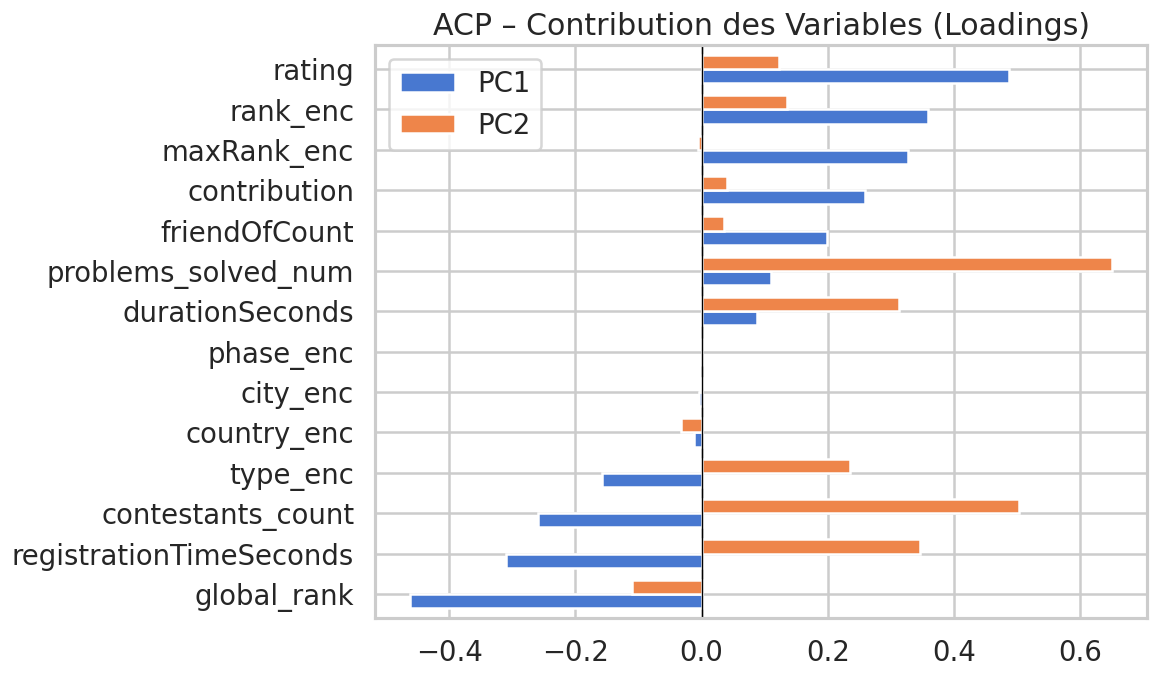

In [ ]:
# ── Loadings Plot ─────────────────────────────────────────────────────────
loadings = pd.DataFrame(pca2.components_.T, index=features,
                        columns=['PC1', 'PC2'])

fig, ax = plt.subplots(figsize=(10, 6))
loadings.sort_values('PC1').plot(kind='barh', ax=ax, width=0.7)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('ACP – Contribution des Variables (Loadings)')
plt.tight_layout()
plt.savefig('01b_pca_loadings.png')
plt.show()

In [16]:
# ── Méthode du coude ─────────────────────────────────────────────────────
inertias = []
K_range  = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertias, 'o-', color='teal', lw=2)
axes[0].set_xlabel('Nombre de clusters k')
axes[0].set_ylabel('Inertie (Within-cluster SS)')
axes[0].set_title('K-Means – Méthode du Coude')
axes[0].grid(True, alpha=0.4)

# ── K-Means final (k=3) ───────────────────────────────────────────────────
BEST_K = 3
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(X_scaled)

sc2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                      c=clusters_km, cmap='viridis', alpha=0.4, s=5)
axes[1].set_title(f'K-Means (k={BEST_K}) – Projection ACP')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.savefig('02_kmeans.png')
plt.show()

unique, counts = np.unique(clusters_km, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u} : {c:,} points ({c/len(clusters_km)*100:.1f}%)")

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

DBSCAN → 15 cluster(s) détecté(s)
         1454 points bruit (29.1%)


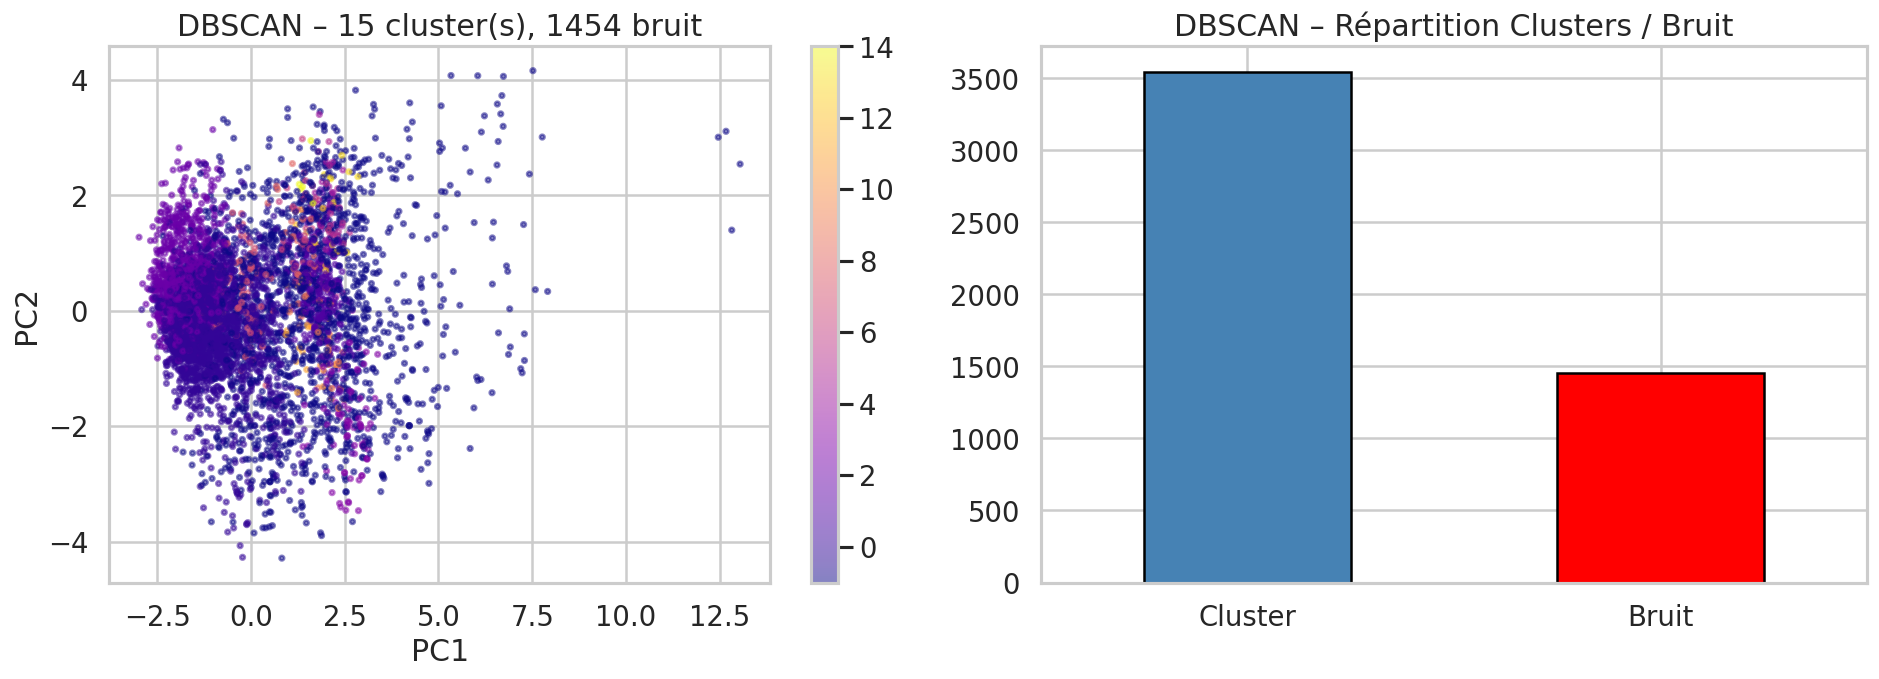

In [ ]:
# ── DBSCAN sur sous-échantillon (max 5 000 pts pour la vitesse) ───────────
N_MAX = 5000
idx_db = np.random.choice(len(X_scaled), min(N_MAX, len(X_scaled)), replace=False)
X_db   = X_scaled[idx_db]
X_pca_db = X_pca[idx_db]

dbscan = DBSCAN(eps=1.5, min_samples=10)
clusters_db = dbscan.fit_predict(X_db)

n_clusters = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise    = list(clusters_db).count(-1)

print(f"DBSCAN → {n_clusters} cluster(s) détecté(s)")
print(f"         {n_noise} points bruit ({n_noise/len(clusters_db)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Résultat DBSCAN
sc3 = axes[0].scatter(X_pca_db[:, 0], X_pca_db[:, 1],
                      c=clusters_db, cmap='plasma', alpha=0.5, s=8)
axes[0].set_title(f'DBSCAN – {n_clusters} cluster(s), {n_noise} bruit')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc3, ax=axes[0])

# Points bruit vs clusters
labels = ['Cluster' if l != -1 else 'Bruit' for l in clusters_db]
pd.Series(labels).value_counts().plot(kind='bar', ax=axes[1],
                                       color=['steelblue','red'],
                                       edgecolor='black')
axes[1].set_title('DBSCAN – Répartition Clusters / Bruit')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('03_dbscan.png')
plt.show()

Train : 245,508   Test : 61,378

✅ Random Forest
   Accuracy : 0.6760
   F1-Score : 0.7381
   CV Accuracy: 0.6487 (+/- 0.0336)
   CV F1-Score: 0.7222 (+/- 0.0153)

              precision    recall  f1-score   support

           0       0.64      0.52      0.58     25796
           1       0.69      0.79      0.74     35582

    accuracy                           0.68     61378
   macro avg       0.67      0.65      0.66     61378
weighted avg       0.67      0.68      0.67     61378



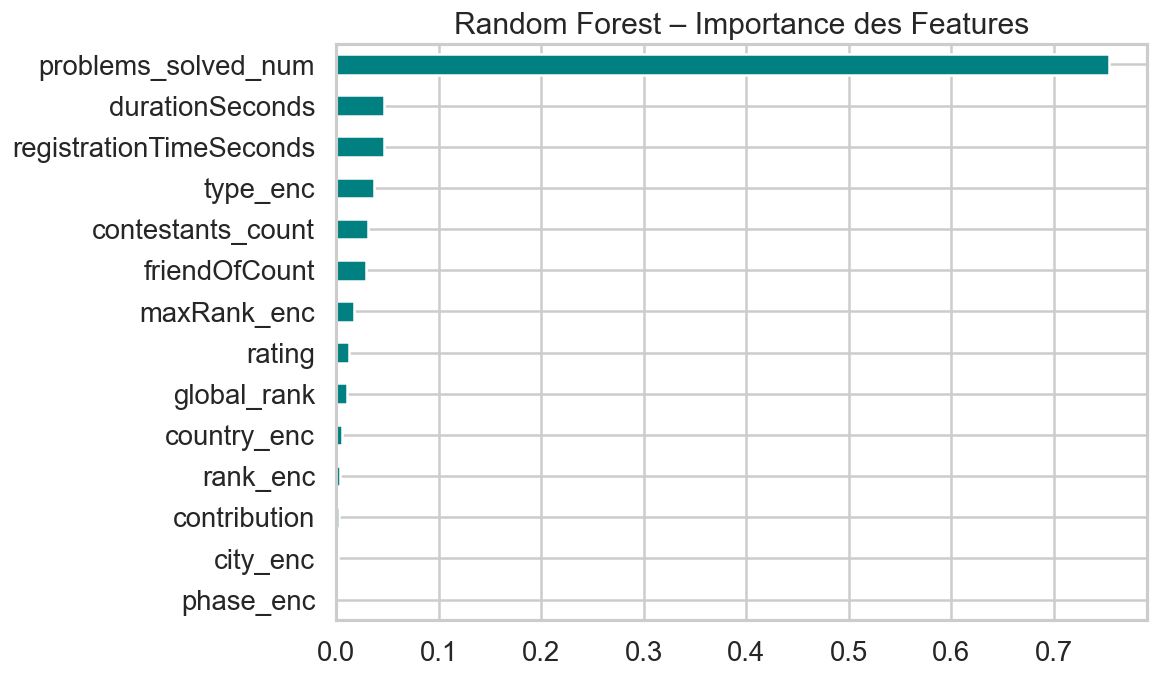

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {len(X_train):,}   Test : {len(X_test):,}")

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print(f"\n✅ Random Forest")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"   F1-Score : {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")

# Add cross-validation scores for a more robust evaluation
from sklearn.model_selection import cross_val_score
cv_accuracy = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(rf, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f"   CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print(f"   CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print()
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Importance des features
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
imp.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Random Forest – Importance des Features')
plt.tight_layout()
plt.savefig('04_rf_feature_importance.png')
plt.show()

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

scaler_svm = StandardScaler()
X_tr_sc = scaler_svm.fit_transform(X_train)
X_te_sc = scaler_svm.transform(X_test)

# Sous-échantillonnage pour l'entraînement
N_SVM = 3000  # ← réduit de 5000 à 3000
idx_svm = np.random.choice(len(X_tr_sc), min(N_SVM, len(X_tr_sc)), replace=False)

svm = SVC(probability=True, random_state=42, C=1.0, kernel='rbf')
svm.fit(X_tr_sc[idx_svm], y_train.iloc[idx_svm])
y_pred_svm = svm.predict(X_te_sc)
y_prob_svm = svm.predict_proba(X_te_sc)[:, 1]

print(f"✅ SVM (RBF)")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"   F1-Score : {f1_score(y_test, y_pred_svm, zero_division=0):.4f}")

# ⚡ CV uniquement sur sous-échantillon pour la vitesse
N_CV = 5000  # ← CV sur 5000 points seulement au lieu de 306k
idx_cv = np.random.choice(len(X), min(N_CV, len(X)), replace=False)
X_cv = X.iloc[idx_cv]
y_cv = y.iloc[idx_cv]

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42, C=1.0, kernel='rbf'))
])

cv_accuracy = cross_val_score(svm_pipeline, X_cv, y_cv, cv=3,  # ← cv=3 au lieu de 5
                               scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(svm_pipeline, X_cv, y_cv, cv=3,
                         scoring='f1', n_jobs=-1)

print(f"   CV Accuracy : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"   CV F1-Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print()
print(classification_report(y_test, y_pred_svm, zero_division=0))

ValueError: Input X contains NaN.
SVC does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

✅ Arbre de Décision (max_depth=6)
   Accuracy : 0.6553
   F1-Score : 0.7343
   CV Accuracy: 0.6503 (+/- 0.0137)
   CV F1-Score: 0.7123 (+/- 0.0506)

              precision    recall  f1-score   support

           0       0.63      0.43      0.51     25796
           1       0.66      0.82      0.73     35582

    accuracy                           0.66     61378
   macro avg       0.65      0.62      0.62     61378
weighted avg       0.65      0.66      0.64     61378



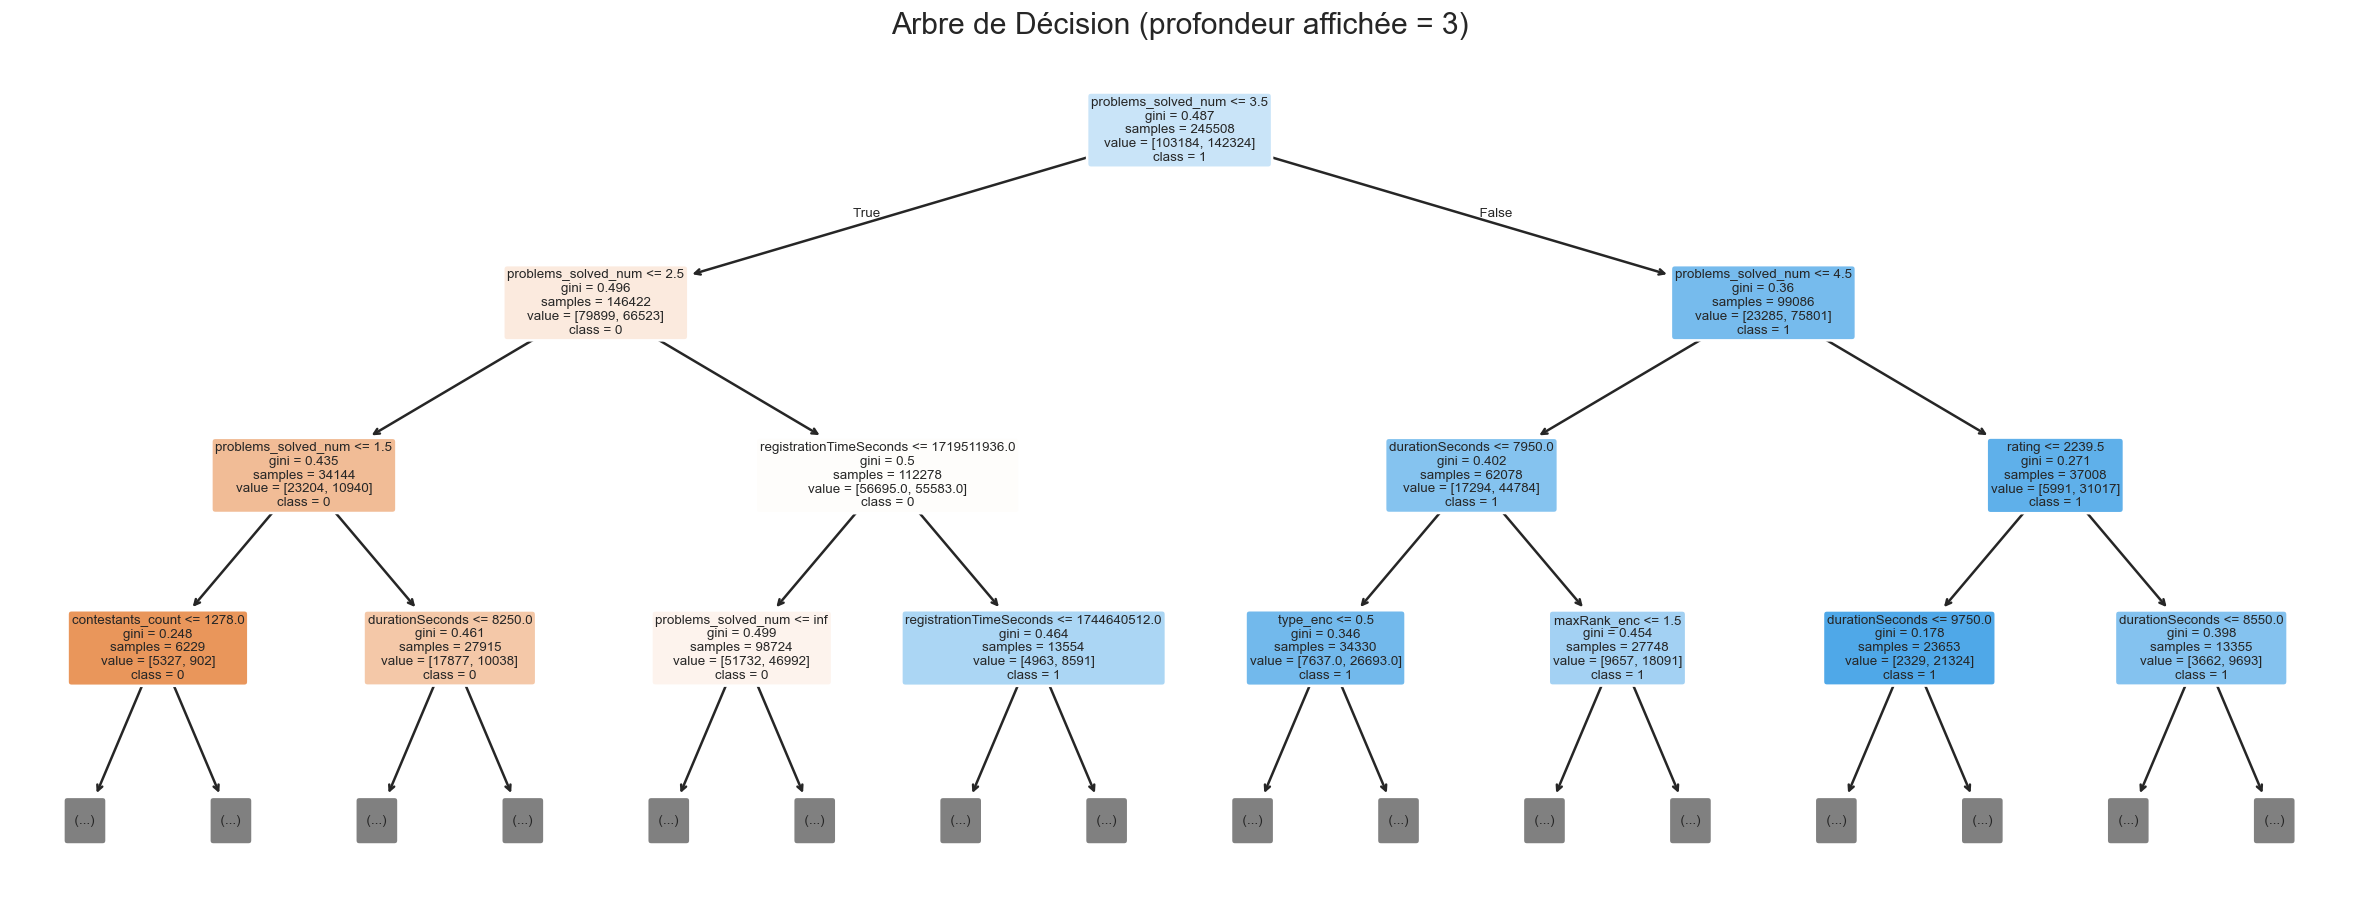

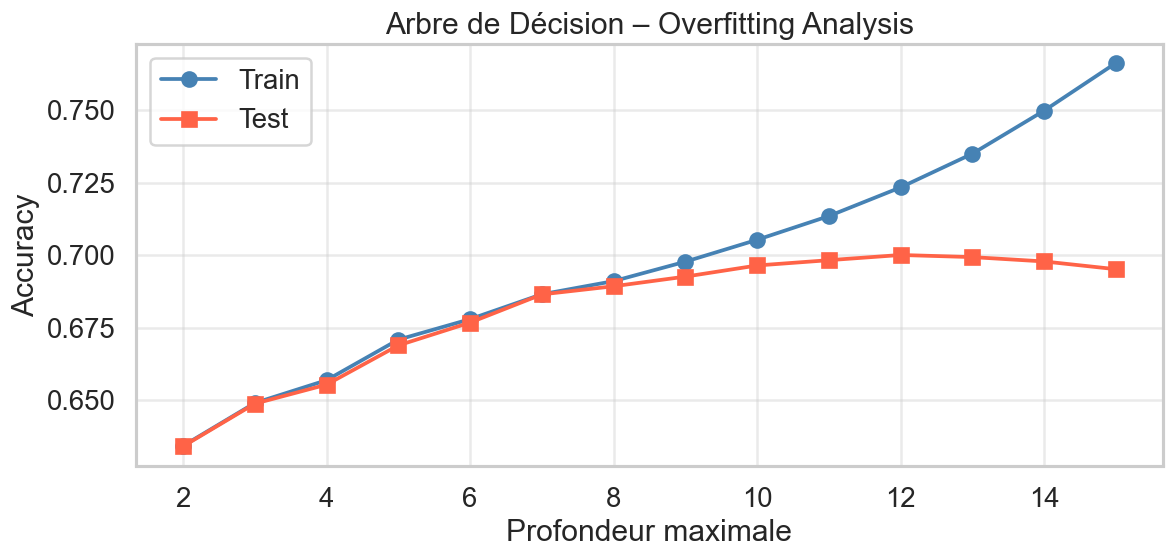

In [19]:
dt = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=15,
    min_samples_split=30,
    random_state=42
)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt  = dt.predict_proba(X_test)[:, 1]

print(f"✅ Arbre de Décision (max_depth=6)")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"   F1-Score : {f1_score(y_test, y_pred_dt, zero_division=0):.4f}")

# Add cross-validation scores for a more robust evaluation
from sklearn.model_selection import cross_val_score
cv_accuracy = cross_val_score(dt, X, y, cv=5, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(dt, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f"   CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print(f"   CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print()
print(classification_report(y_test, y_pred_dt, zero_division=0))

# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=features, class_names=['0','1'],
          filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax)
ax.set_title('Arbre de Décision (profondeur affichée = 3)')
plt.tight_layout()
plt.savefig('05_decision_tree.png')
plt.show()

# Profondeur vs Accuracy
depths   = range(2, 16)
accs_tr  = []
accs_te  = []
for d in depths:
    tmp = DecisionTreeClassifier(max_depth=d, random_state=42)
    tmp.fit(X_train, y_train)
    accs_tr.append(accuracy_score(y_train, tmp.predict(X_train)))
    accs_te.append(accuracy_score(y_test,  tmp.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, accs_tr, 'o-', label='Train', color='steelblue')
ax.plot(depths, accs_te, 's-', label='Test',  color='tomato')
ax.set_xlabel('Profondeur maximale')
ax.set_ylabel('Accuracy')
ax.set_title('Arbre de Décision – Overfitting Analysis')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('05b_dt_depth_analysis.png')
plt.show()

In [20]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr  = lr.predict_proba(X_test)[:, 1]

print(f"✅ Régression Logistique")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"   F1-Score : {f1_score(y_test, y_pred_lr, zero_division=0):.4f}")

# Add cross-validation scores for a more robust evaluation
from sklearn.model_selection import cross_val_score
cv_accuracy = cross_val_score(lr, X, y, cv=5, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(lr, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f"   CV Accuracy: {cv_accuracy.mean():.4f} (+/- {cv_accuracy.std():.4f})")
print(f"   CV F1-Score: {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
print()
print(classification_report(y_test, y_pred_lr, zero_division=0))

# Coefficients
coef = pd.Series(lr.coef_[0], index=features).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
coef.plot(kind='barh', ax=ax, color=coef.map(lambda v: 'steelblue' if v >= 0 else 'tomato'))
ax.axvline(0, color='black', lw=1)
ax.set_title('Régression Logistique – Coefficients')
plt.tight_layout()
plt.savefig('06_logistic_coefficients.png')
plt.show()

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [21]:
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred_reg = reg.predict(X_test)

r2  = r2_score(y_test, y_pred_reg)
mse = mean_squared_error(y_test, y_pred_reg)
rmse = np.sqrt(mse)

print(f"✅ Régression Linéaire")
print(f"   R²   = {r2:.4f}")
print(f"   MSE  = {mse:.4f}")
print(f"   RMSE = {rmse:.4f}")

# Add cross-validation scores for regression metrics
from sklearn.model_selection import KFold, cross_val_score
cv_r2 = cross_val_score(reg, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2', n_jobs=-1)
cv_mse = -cross_val_score(reg, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='neg_mean_squared_error', n_jobs=-1)

print(f"   CV R²   : {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
print(f"   CV MSE  : {cv_mse.mean():.4f} (+/- {cv_mse.std():.4f})")
print(f"   CV RMSE : {np.sqrt(cv_mse.mean()):.4f} (+/- {np.sqrt(cv_mse.std()):.4f})") # RMSE of mean MSE
print()

coef_r = pd.Series(reg.coef_, index=features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

coef_r.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Régression Linéaire – Coefficients')

axes[1].scatter(y_test, y_pred_reg, alpha=0.3, s=5, color='coral')
lims = [min(y_test.min(), y_pred_reg.min()), max(y_test.max(), y_pred_reg.max())]
axes[1].plot(lims, lims, 'k--', lw=1, label='Parfait')
axes[1].set_xlabel('Valeurs réelles')
axes[1].set_ylabel('Valeurs prédites')
axes[1].set_title(f'Régression Linéaire (R²={r2:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('07_linear_regression.png')
plt.show()

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train)
X_test_mlp  = scaler_mlp.transform(X_test)

# ✅ CORRECTION OVERFITTING : alpha (L2) + early_stopping + couches réduites
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # ← réduit : 100,50 → 64,32
    activation='relu',
    solver='adam',
    alpha=0.01,                   # ← nouveau : régularisation L2 (était 0.0001)
    learning_rate='adaptive',     # ← nouveau
    max_iter=500,
    early_stopping=True,          # ← garde le early stopping
    validation_fraction=0.15,     # ← augmenté de 0.1 à 0.15
    n_iter_no_change=15,          # ← nouveau : patience plus longue
    random_state=42,
    verbose=False
)

mlp.fit(X_train_mlp, y_train)
y_pred_mlp = mlp.predict(X_test_mlp)
y_prob_mlp = mlp.predict_proba(X_test_mlp)[:, 1]

print(f"✅ MLP – Accuracy : {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"   MLP – F1-Score : {f1_score(y_test, y_pred_mlp, zero_division=0):.4f}")
print(f"   Nombre d'itérations réelles : {mlp.n_iter_}")

# Cross-validation pour vérifier qu'il n'y a PAS d'overfitting
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32), activation='relu',
        solver='adam', alpha=0.01, learning_rate='adaptive',
        max_iter=500, early_stopping=True, validation_fraction=0.15,
        n_iter_no_change=15, random_state=42
    ))
])
cv_acc = cross_val_score(mlp_pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(mlp_pipeline, X, y, cv=5, scoring='f1', n_jobs=-1)
print(f"\n📊 Cross-Validation (5 folds) :")
print(f"   CV Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"   CV F1-Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"\n{'─'*40}")
print(f"   Train Accuracy : {accuracy_score(y_train, mlp.predict(X_train_mlp)):.4f}")
print(f"   Test  Accuracy : {accuracy_score(y_test,  y_pred_mlp):.4f}")
gap = accuracy_score(y_train, mlp.predict(X_train_mlp)) - accuracy_score(y_test, y_pred_mlp)
print(f"   Gap Train-Test : {gap:.4f}  {'✅ OK' if gap < 0.05 else '⚠️ Overfitting!'}")

# Courbe de loss
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp.loss_curve_, color='darkred', lw=2, label='Train Loss')
if hasattr(mlp, 'validation_scores_'):
    ax.plot(mlp.validation_scores_, color='steelblue', lw=2,
            linestyle='--', label='Val Accuracy')
ax.set_xlabel("Itération")
ax.set_ylabel("Loss / Score")
ax.set_title("MLP – Courbe d'apprentissage")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('09_mlp_loss_curve.png')
plt.show()
print(classification_report(y_test, y_pred_mlp, zero_division=0))

ValueError: Input X contains NaN.
MLPClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [23]:
# ── Récapitulatif des performances ───────────────────────────────────────

# ⚡ Sous-échantillon pour la CV (évite 30+ minutes d'attente)
N_CV = 5000
idx_cv = np.random.choice(len(X), min(N_CV, len(X)), replace=False)
X_cv = X.iloc[idx_cv]
y_cv = y.iloc[idx_cv]

# Modèles corrigés anti-overfitting
rf_summary = RandomForestClassifier(n_estimators=100, max_depth=6,
                                     min_samples_leaf=10, min_samples_split=20,
                                     max_features='sqrt', random_state=42, n_jobs=-1)
svm_pipeline_summary = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42, C=1.0, kernel='rbf'))
])
dt_summary = DecisionTreeClassifier(max_depth=4, min_samples_leaf=15,
                                     min_samples_split=30, random_state=42)
lr_summary = LogisticRegression(max_iter=500, random_state=42)
mlp_pipeline_summary = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                          solver='adam', alpha=0.01, learning_rate='adaptive',
                          max_iter=500, early_stopping=True,
                          validation_fraction=0.15, n_iter_no_change=15,
                          random_state=42, verbose=False))
])

all_results = {
    'Random Forest'      : {'y_pred': y_pred_rf,  'y_prob': y_prob_rf,  'model': rf_summary},
    'SVM (RBF)'          : {'y_pred': y_pred_svm, 'y_prob': y_prob_svm, 'model': svm_pipeline_summary},
    'Arbre de Décision'  : {'y_pred': y_pred_dt,  'y_prob': y_prob_dt,  'model': dt_summary},
    'Régr. Logistique'   : {'y_pred': y_pred_lr,  'y_prob': y_prob_lr,  'model': lr_summary},
    'Réseau de Neurones' : {'y_pred': y_pred_mlp, 'y_prob': y_prob_mlp, 'model': mlp_pipeline_summary},
}

perf = {}
for name, r in all_results.items():
    accuracy = accuracy_score(y_test, r['y_pred'])
    f1       = f1_score(y_test, r['y_pred'], zero_division=0)
    roc_auc  = auc(*roc_curve(y_test, r['y_prob'])[:2])

    # ⚡ CV sur sous-échantillon + 3 folds au lieu de 5
    cv_acc = cross_val_score(r['model'], X_cv, y_cv, cv=3,
                              scoring='accuracy', n_jobs=-1)
    cv_f1  = cross_val_score(r['model'], X_cv, y_cv, cv=3,
                              scoring='f1', n_jobs=-1)

    # Diagnostic overfitting
    gap = accuracy - cv_acc.mean()
    status = '✅ OK' if abs(gap) < 0.05 else '⚠️ Overfitting'

    perf[name] = {
        'Test Accuracy'   : accuracy,
        'Test F1'         : f1,
        'Test AUC'        : roc_auc,
        'CV Accuracy'     : cv_acc.mean(),
        'CV Accuracy Std' : cv_acc.std(),
        'CV F1'           : cv_f1.mean(),
        'Gap Test-CV'     : gap,
        'Statut'          : status,
    }

perf_df = pd.DataFrame(perf).T.sort_values('Test Accuracy', ascending=False)
print("\n📊 TABLEAU COMPARATIF")
print(perf_df.to_string(float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else str(x)))

NameError: name 'y_pred_svm' is not defined

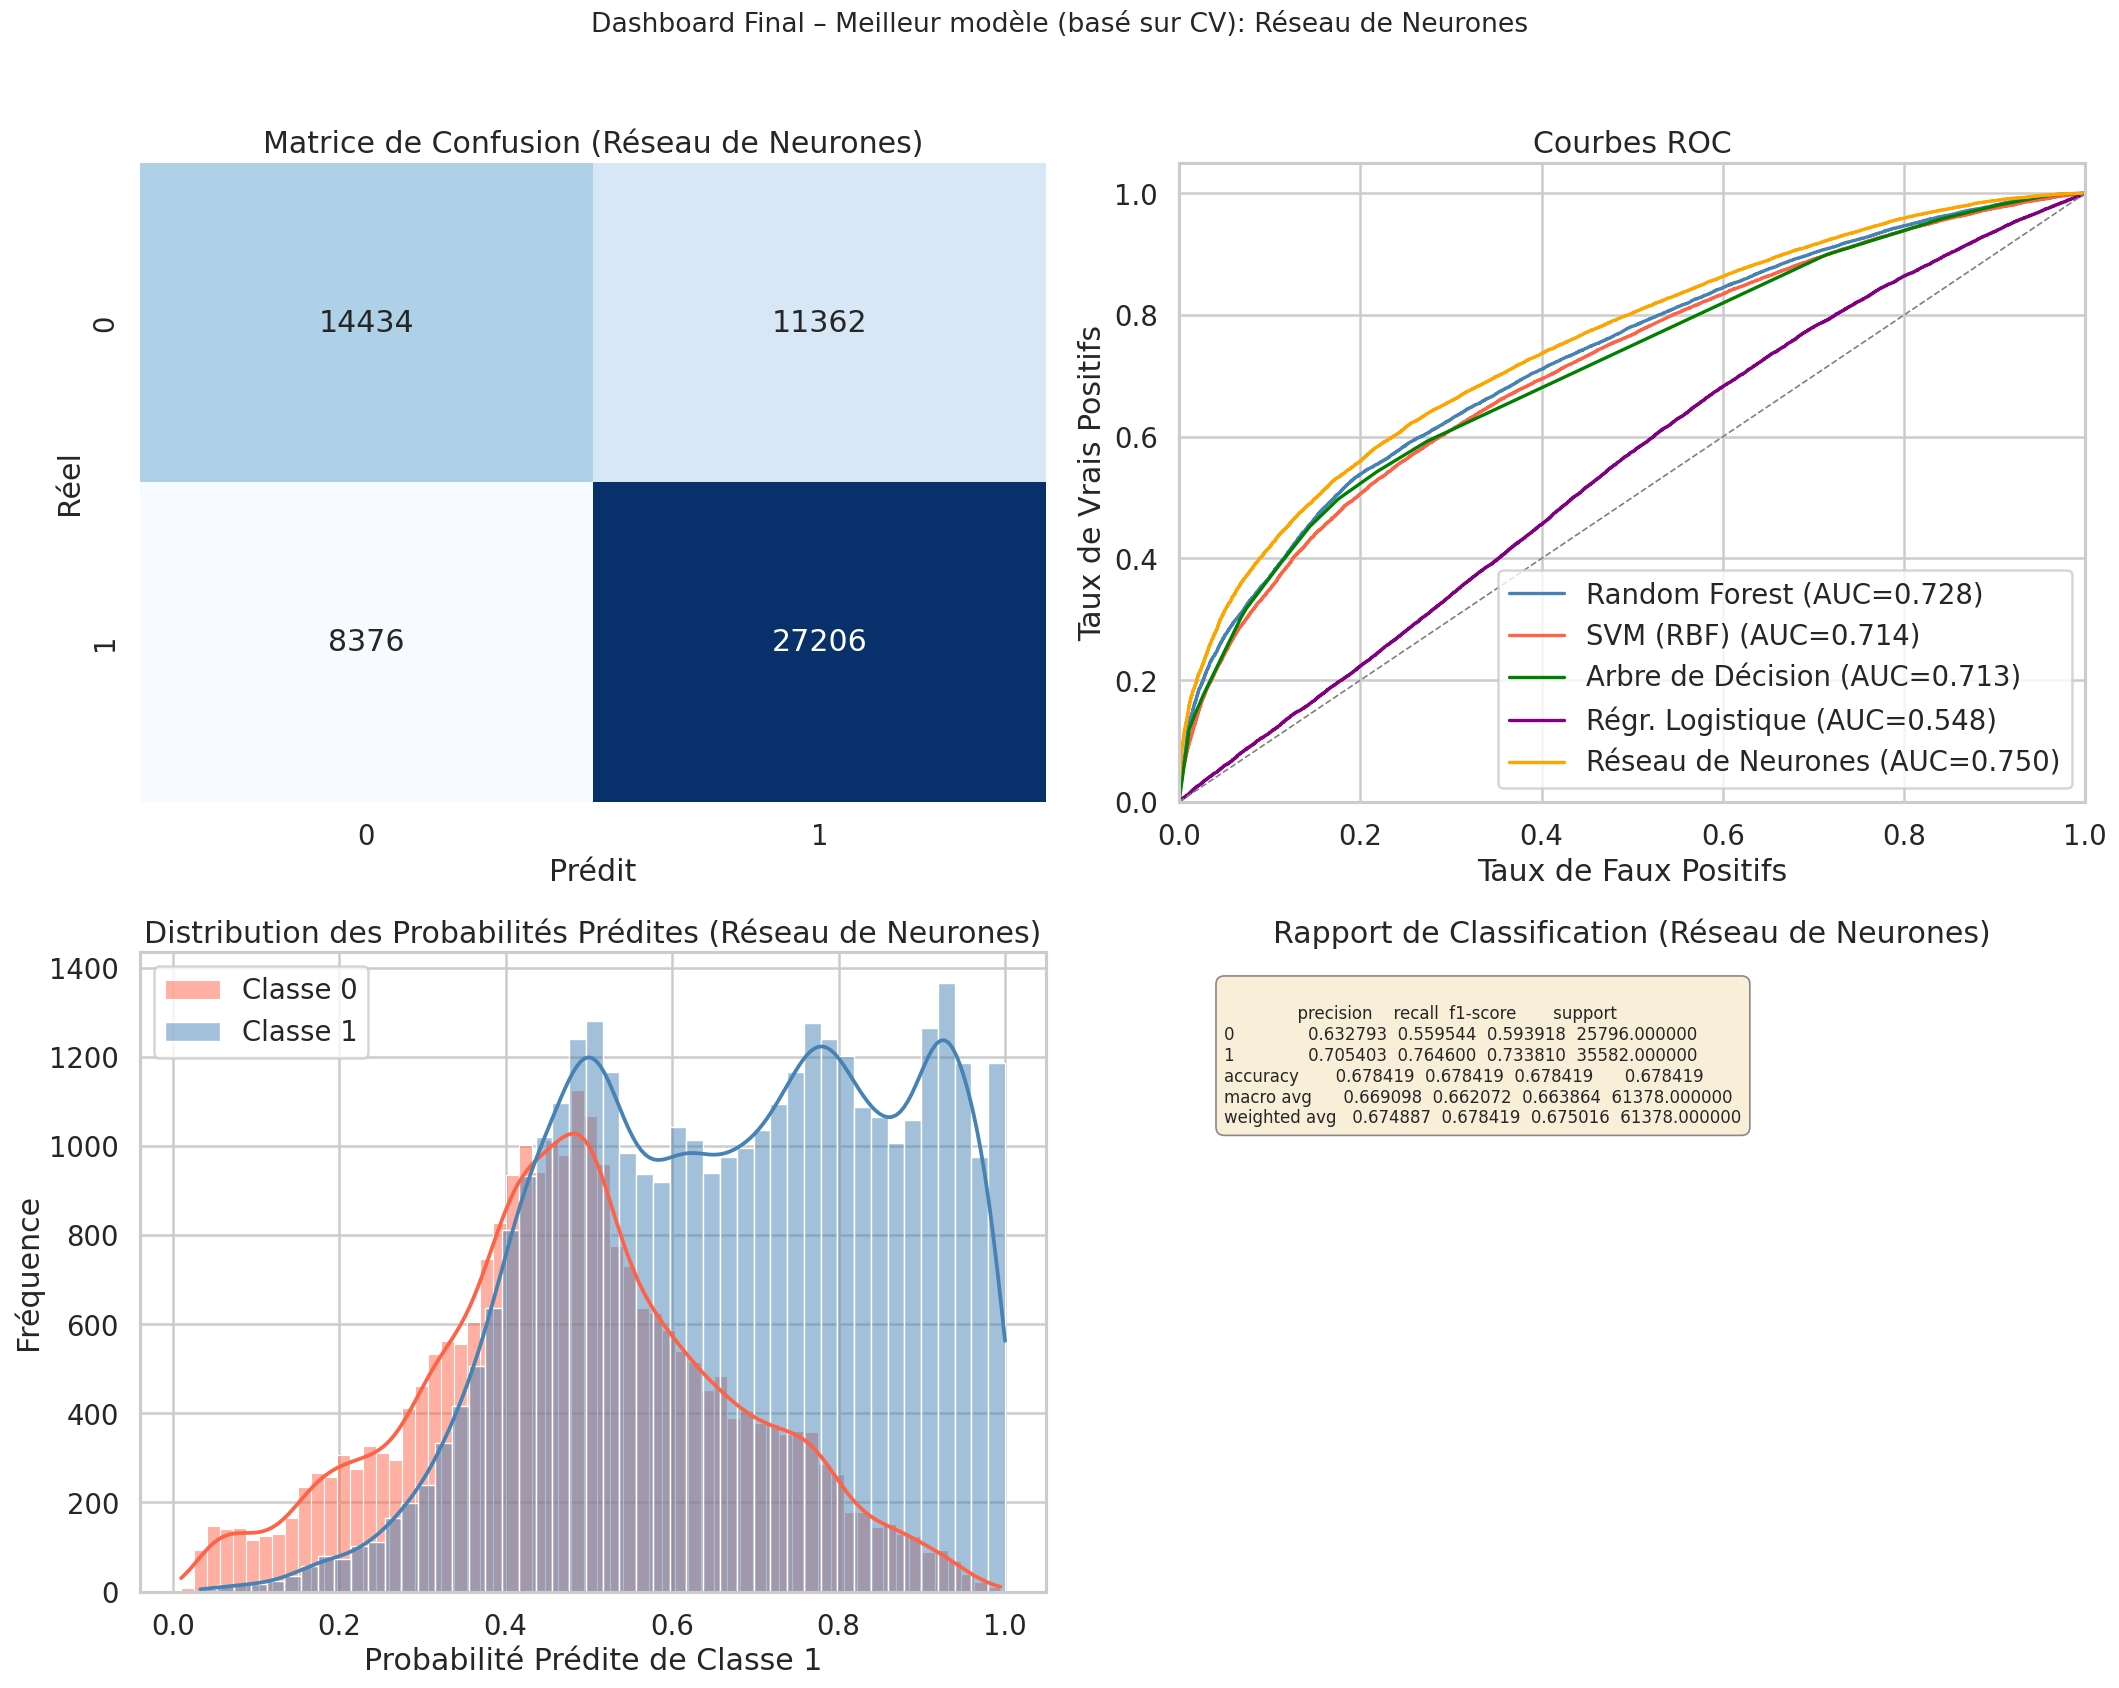

In [ ]:
# ── Dashboard 2×2 ─────────────────────────────────────────────────────────

# Selecting the best model based on CV Accuracy Mean for better generalization
# Need to handle potential KeyError if Linear Regression is included in perf_df and doesn't have 'CV Accuracy Mean'
classification_models_perf = perf_df.loc[perf_df.index.difference(['Régression Linéaire'])]
if not classification_models_perf.empty:
    best_name = classification_models_perf['CV Accuracy'].idxmax()
else:
    # Fallback if only regression model is present or no CV Accuracy Mean is available
    best_name = perf_df['Test Accuracy'].idxmax() if 'Test Accuracy' in perf_df.columns else perf_df.index[0]

best_pred = all_results[best_name]['y_pred']
best_prob = all_results[best_name]['y_prob']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Dashboard Final – Meilleur modèle (basé sur CV): {best_name}', fontsize=16, y=1.01)

# Matrice de confusion
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt='d', cmap='Blues',
            cbar=False, ax=axes[0, 0], xticklabels=['0', '1'], yticklabels=['0', '1'])
axes[0, 0].set_title(f'Matrice de Confusion ({best_name})')
axes[0, 0].set_xlabel('Prédit')
axes[0, 0].set_ylabel('Réel')

# Courbes ROC – tous les modèles
colors = ['steelblue', 'tomato', 'green', 'purple', 'orange']  # Added one more color for MLP
for (name, r), col in zip(all_results.items(), colors):
    if name != 'Régression Linéaire': # Only plot ROC for classification models
        fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
        roc_auc = auc(fpr, tpr)
        axes[0, 1].plot(fpr, tpr, lw=2, color=col,
                        label=f'{name} (AUC={roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('Taux de Faux Positifs')
axes[0, 1].set_ylabel('Taux de Vrais Positifs')
axes[0, 1].set_title('Courbes ROC')
axes[0, 1].legend(loc='lower right')

# Distribution des probabilités prédites
sns.histplot(best_prob[y_test == 0], color='tomato', label='Classe 0', kde=True, ax=axes[1, 0])
sns.histplot(best_prob[y_test == 1], color='steelblue', label='Classe 1', kde=True, ax=axes[1, 0])
axes[1, 0].set_title(f'Distribution des Probabilités Prédites ({best_name})')
axes[1, 0].set_xlabel('Probabilité Prédite de Classe 1')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].legend()

# Report de Classification Détaillé
report_str = classification_report(y_test, best_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_str).transpose()
axes[1, 1].axis('off') # Hide axes for text
axes[1, 1].text(0.05, 0.95, "\n" + report_df.to_string(),
               verticalalignment='top', horizontalalignment='left', fontsize=10,
               bbox=dict(boxstyle='round,pad=0.5', fc='wheat', ec='k', lw=1, alpha=0.5))
axes[1, 1].set_title(f'Rapport de Classification ({best_name})')


plt.tight_layout()
plt.subplots_adjust(top=0.92) # Adjust suptitle position
plt.savefig('10_dashboard_final.png')
plt.show()

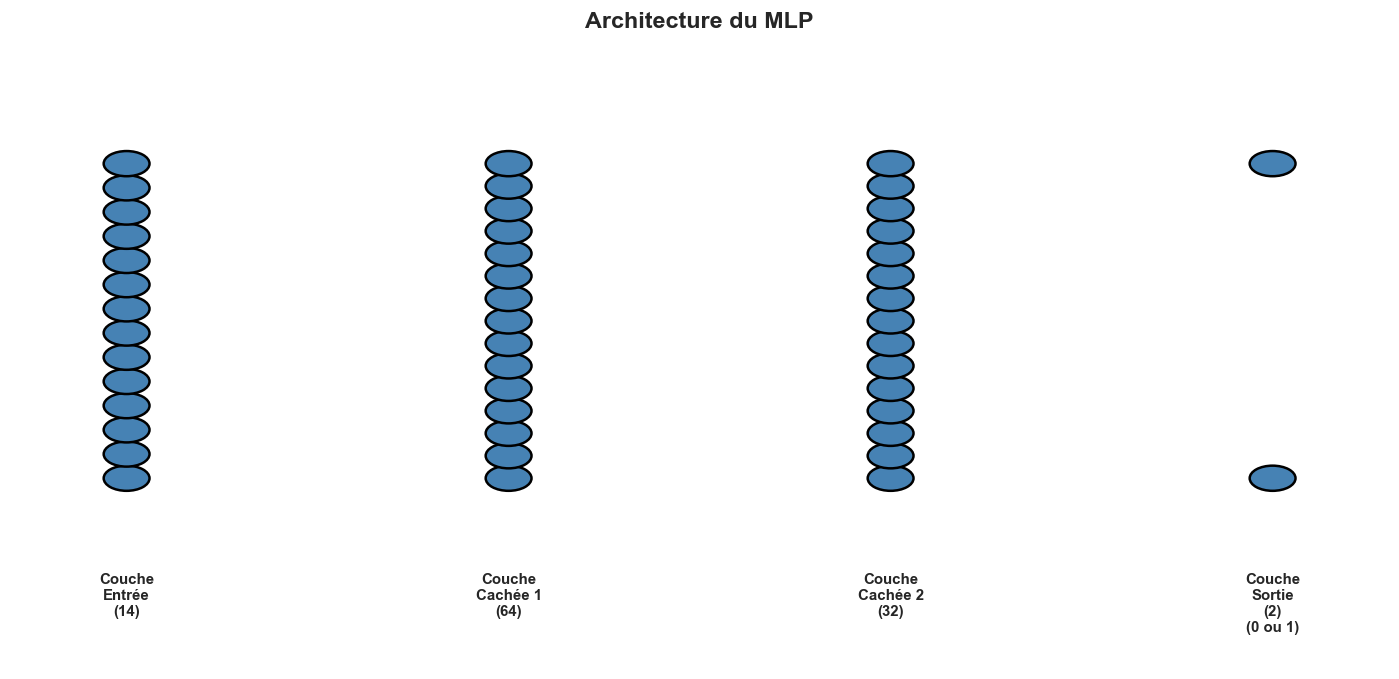

In [24]:
# ── Visualisation simplifiée de l'architecture du MLP ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# Paramètres du réseau
layer_sizes = [X_train_mlp.shape[1]] + list(mlp.hidden_layer_sizes) + [2]  # 2 classes
n_layers = len(layer_sizes)

# Positions verticales
pos_y = np.linspace(0.2, 0.8, max(layer_sizes))

for i, (n_neurons, next_n) in enumerate(zip(layer_sizes, layer_sizes[1:] + [None])):
    x = i / (n_layers - 1)

    # Cercles des neurones
    for j in range(min(n_neurons, 15)):  # max 15 pour lisibilité
        y = 0.3 + (j / max(1, min(n_neurons, 15)-1)) * 0.5
        circle = plt.Circle((x, y), 0.02, color='steelblue', ec='black', zorder=3)
        ax.add_patch(circle)

    # Label couche
    if i == 0:
        label = f"Couche\nEntrée\n({n_neurons})"
    elif i == n_layers - 1:
        label = f"Couche\nSortie\n({n_neurons})\n(0 ou 1)"
    else:
        label = f"Couche\nCachée {i}\n({n_neurons})"

    ax.text(x, 0.15, label, ha='center', va='top', fontsize=9, fontweight='bold')

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0, 1)
ax.set_title("Architecture du MLP", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09b_mlp_architecture.png')
plt.show()

In [26]:
# ── Afficher les figures générées ───────────────────────────────────────────
import glob
import os

print("📊 Figures générées :")
png_files = sorted(glob.glob('*.png'))
for f in png_files:
    size = os.path.getsize(f) / 1024
    print(f"   ✔ {f}  ({size:.0f} KB)")

print(f"\n✅ {len(png_files)} fichiers PNG disponibles dans le répertoire courant")
print(f"   Chemin : {os.getcwd()}")

📊 Figures générées :
   ✔ 05b_dt_depth_analysis.png  (55 KB)
   ✔ 09b_mlp_architecture.png  (49 KB)

✅ 2 fichiers PNG disponibles dans le répertoire courant
   Chemin : c:\Users\khalf\Pi\Esprit-PI-4Twin1-2026-ByteBattle


In [27]:
import os
print([f for f in os.listdir('.') if f.endswith('.csv')])

['contests.csv', 'rating_changes.csv', 'users.csv']


⏳ Construction de la matrice utilisateur-contests...
CSV disponibles : ['contests.csv', 'rating_changes.csv', 'users.csv']
Fichier utilisé : rating_changes.csv
✅ 306,886 lignes chargées
   Colonnes : ['Unnamed: 0', 'handle', 'contestId', 'oldRating', 'newRating', 'problems_solved', 'problems_solved_num']
✅ Matrice : 4949 utilisateurs × 1714 contests

⏳ Calcul de la similarité entre utilisateurs...
✅ Matrice de similarité : (1000, 1000)

🎯 Recommandations pour : 'AliRagab313'
───────────────────────────────────────────────────────
 contestId    Score                          name
      2178 9.564169                 Good Bye 2025
      1888 8.736610 Codeforces Round 905 (Div. 2)
      2035 8.671952    Codeforces Global Round 27
      1904 8.326232 Codeforces Round 914 (Div. 2)
      2001 8.252173 Codeforces Round 967 (Div. 2)


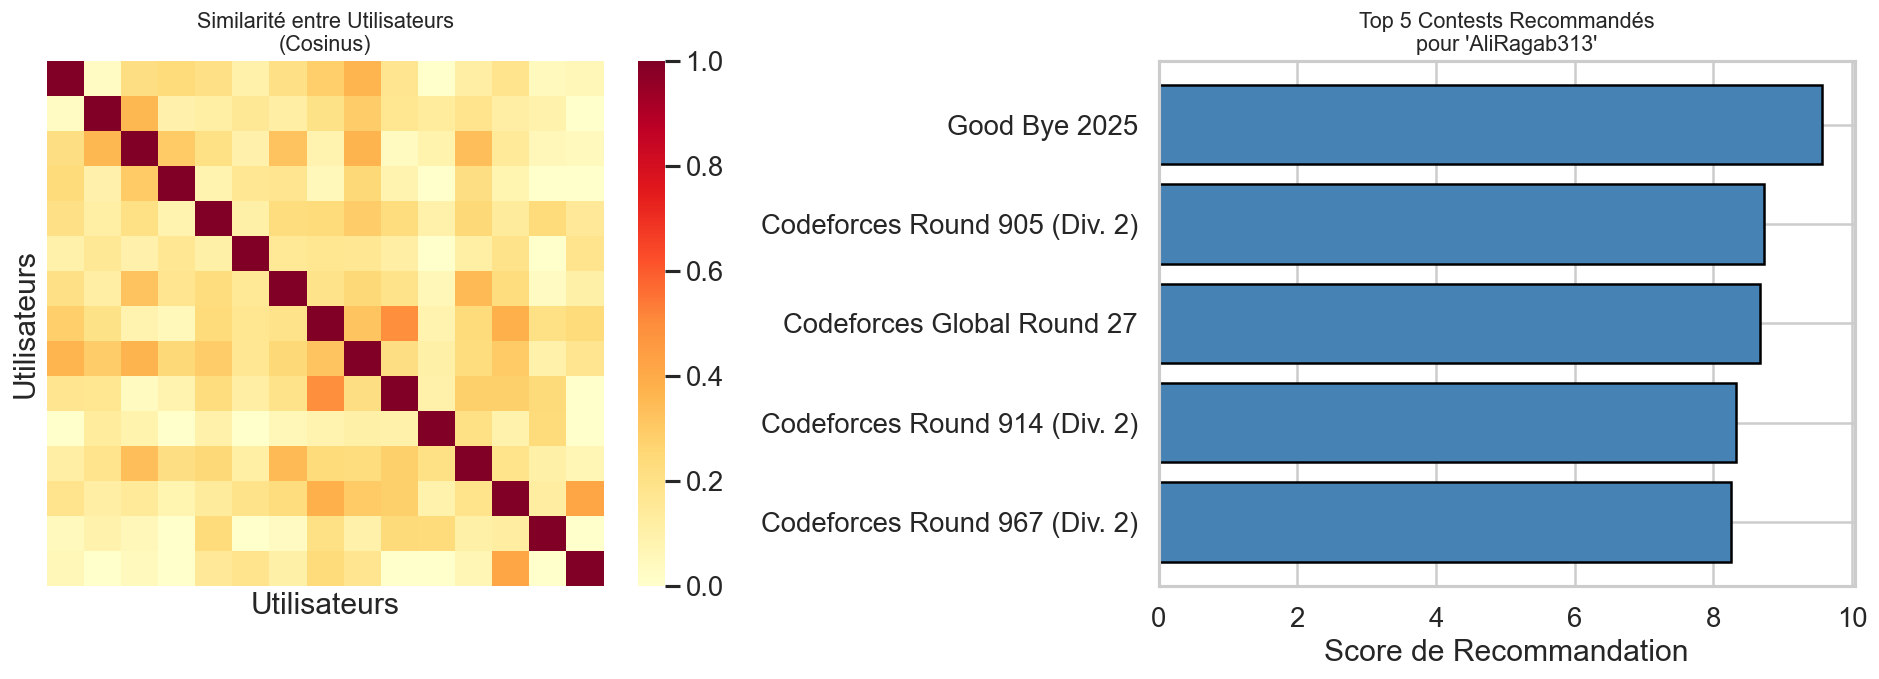


✅ Système de recommandation terminé !


In [28]:
# ═══════════════════════════════════════════════════════════════
# SYSTÈME DE RECOMMANDATION DE CHALLENGES
# Filtrage Collaboratif basé sur les problèmes résolus
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# ── 1. Construction de la matrice utilisateur-contests ───────────────────
print("⏳ Construction de la matrice utilisateur-contests...")

# Charger rating_changes directement (avant la fusion)
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print(f"CSV disponibles : {csv_files}")

# Prend le fichier qui contient 'rating' dans son nom
rating_file = next((f for f in csv_files if 'rating' in f.lower()), csv_files[0])
print(f"Fichier utilisé : {rating_file}")
rc = pd.read_csv(rating_file)
print(f"✅ {rc.shape[0]:,} lignes chargées")
print(f"   Colonnes : {list(rc.columns)}")

# Garder uniquement les colonnes utiles
rc_clean = rc[['handle', 'contestId', 'problems_solved_num']].dropna()

# Pivoter : lignes = utilisateurs, colonnes = contests
# valeur = nb problèmes résolus (0 si absent)
user_contest_matrix = rc_clean.pivot_table(
    index='handle',
    columns='contestId',
    values='problems_solved_num',
    fill_value=0
)

print(f"✅ Matrice : {user_contest_matrix.shape[0]} utilisateurs × {user_contest_matrix.shape[1]} contests")

# ── 2. Similarité cosinus entre utilisateurs ──────────────────────────────
print("\n⏳ Calcul de la similarité entre utilisateurs...")

# Sous-échantillon pour la vitesse (max 1000 users)
N_USERS = min(1000, len(user_contest_matrix))
user_sample = user_contest_matrix.sample(N_USERS, random_state=42)

similarity_matrix = cosine_similarity(user_sample)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=user_sample.index,
    columns=user_sample.index
)
print(f"✅ Matrice de similarité : {similarity_df.shape}")

# ── 3. Fonction de recommandation ─────────────────────────────────────────
def recommander_contests(handle, n_similar=5, n_recommandations=5):
    """
    Pour un utilisateur donné, recommande des contests
    basés sur les utilisateurs les plus similaires.
    """
    if handle not in similarity_df.index:
        print(f"❌ Utilisateur '{handle}' non trouvé dans le sous-échantillon.")
        print(f"   Utilisateurs disponibles (5 exemples) : {list(similarity_df.index[:5])}")
        return None

    # Utilisateurs les plus similaires
    similar_users = (
        similarity_df[handle]
        .drop(handle)               # exclure lui-même
        .sort_values(ascending=False)
        .head(n_similar)
    )

    # Contests déjà faits par l'utilisateur cible
    contests_faits = set(
        user_sample.loc[handle][user_sample.loc[handle] > 0].index
    )

    # Contests populaires chez les utilisateurs similaires
    # pondérés par leur similarité
    scores = {}
    for similar_handle, sim_score in similar_users.items():
        contests_similaire = user_sample.loc[similar_handle]
        for contest_id, nb_solved in contests_similaire.items():
            if contest_id not in contests_faits and nb_solved > 0:
                if contest_id not in scores:
                    scores[contest_id] = 0
                scores[contest_id] += sim_score * nb_solved

    if not scores:
        print(f"⚠️ Aucune recommandation trouvée pour '{handle}'")
        return None

    # Top N recommandations
    recommandations = pd.Series(scores).sort_values(ascending=False).head(n_recommandations)

    # Enrichir avec le nom du contest si disponible
    contests_info = pd.read_csv('contests.csv')[['contestId', 'name']].drop_duplicates()
    result = recommandations.reset_index()
    result.columns = ['contestId', 'Score']
    result = result.merge(contests_info, on='contestId', how='left')
    result['contestId'] = result['contestId'].astype(int)

    return result

# ── 4. Démonstration sur un utilisateur réel ─────────────────────────────
# Prendre le premier utilisateur disponible dans le sous-échantillon
exemple_user = similarity_df.index[0]
print(f"\n🎯 Recommandations pour : '{exemple_user}'")
print(f"{'─'*55}")

reco = recommander_contests(exemple_user, n_similar=5, n_recommandations=5)
if reco is not None:
    print(reco.to_string(index=False))

# ── 5. Visualisation ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap similarité (top 15 users)
top15 = similarity_df.iloc[:15, :15]
sns.heatmap(top15, cmap='YlOrRd', ax=axes[0],
            xticklabels=False, yticklabels=False)
axes[0].set_title('Similarité entre Utilisateurs\n(Cosinus)', fontsize=13)
axes[0].set_xlabel('Utilisateurs')
axes[0].set_ylabel('Utilisateurs')

# Score des recommandations
if reco is not None:
    labels = reco['name'].fillna(reco['contestId'].astype(str))
    axes[1].barh(labels[::-1], reco['Score'][::-1],
                 color='steelblue', edgecolor='black')
    axes[1].set_title(f"Top 5 Contests Recommandés\npour '{exemple_user}'", fontsize=13)
    axes[1].set_xlabel('Score de Recommandation')

plt.tight_layout()
plt.savefig('11_recommandation.png')
plt.show()

print("\n✅ Système de recommandation terminé !")

In [29]:
# Teste avec n'importe quel handle du dataset
recommander_contests("AliRagab313", n_similar=5, n_recommandations=5)

,contestId,Score,name
0,2178,9.564169,Good Bye 2025
1,1888,8.736610,Codeforces Round 905 (Div. 2)
2,2035,8.671952,Codeforces Global Round 27
3,1904,8.326232,Codeforces Round 914 (Div. 2)
4,2001,8.252173,Codeforces Round 967 (Div. 2)


In [30]:
# ═══════════════════════════════════════════════════════════════
# 🔥 HYBRID RECOMMENDER SYSTEM (PCA + KMeans + CF)
# Production-ready / scalable / robuste
# ═══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

print("⏳ Initialisation du système de recommandation hybride...")

# ───────────────────────────────────────────────────────────────
# 1. PREPROCESSING
# ───────────────────────────────────────────────────────────────

# Normalisation (important pour cosine + PCA)
scaler = StandardScaler(with_mean=False)  # sparse safe
user_matrix_scaled = scaler.fit_transform(user_sample)

# ───────────────────────────────────────────────────────────────
# 2. PCA (réduction de dimension)
# ───────────────────────────────────────────────────────────────

N_COMPONENTS = min(50, user_matrix_scaled.shape[1])

pca = PCA(n_components=N_COMPONENTS, random_state=42)
user_pca = pca.fit_transform(user_matrix_scaled)

print(f"✅ PCA: {N_COMPONENTS} composantes | variance expliquée = {pca.explained_variance_ratio_.sum()*100:.2f}%")

# ───────────────────────────────────────────────────────────────
# 3. KMEANS CLUSTERING
# ───────────────────────────────────────────────────────────────

BEST_K = 5  # tu peux tuner ça
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=20)
clusters = kmeans.fit_predict(user_pca)

user_clusters = pd.DataFrame({
    'handle': user_sample.index,
    'cluster': clusters
}).set_index('handle')

print(f"✅ KMeans: {BEST_K} clusters créés")

# ───────────────────────────────────────────────────────────────
# 4. SIMILARITY MATRIX (GLOBAL + LOCAL)
# ───────────────────────────────────────────────────────────────

# Global (fallback)
global_similarity = cosine_similarity(user_pca)
global_sim_df = pd.DataFrame(
    global_similarity,
    index=user_sample.index,
    columns=user_sample.index
)

print("✅ Matrice de similarité globale calculée")

# ───────────────────────────────────────────────────────────────
# 5. HYBRID RECOMMENDER FUNCTION
# ───────────────────────────────────────────────────────────────

def recommander_hybride(handle, n_similar=10, n_recommandations=5):
    """
    Hybrid recommender:
    - Cluster filtering (KMeans)
    - Similarity (cosine)
    - Weighted scoring
    - Fallback global CF
    """

    if handle not in user_sample.index:
        print(f"❌ Utilisateur '{handle}' introuvable")
        return None

    # ── Cluster selection
    cluster_id = user_clusters.loc[handle, 'cluster']
    cluster_users = user_clusters[user_clusters['cluster'] == cluster_id].index

    # ── Edge case: cluster trop petit
    if len(cluster_users) < 3:
        print("⚠️ Cluster trop petit → fallback global")
        sim_df = global_sim_df
    else:
        cluster_pca = user_pca[[user_sample.index.get_loc(u) for u in cluster_users]]
        sim_matrix = cosine_similarity(cluster_pca)
        sim_df = pd.DataFrame(sim_matrix, index=cluster_users, columns=cluster_users)

    # ── Similar users
    similar_users = (
        sim_df[handle]
        .drop(handle, errors='ignore')
        .sort_values(ascending=False)
        .head(n_similar)
    )

    if similar_users.empty:
        print("⚠️ Aucun voisin trouvé → fallback global")
        similar_users = (
            global_sim_df[handle]
            .drop(handle)
            .sort_values(ascending=False)
            .head(n_similar)
        )

    # ── Contests déjà faits
    user_vector = user_sample.loc[handle]
    contests_faits = set(user_vector[user_vector > 0].index)

    # ─────────────────────────────────────────
    # SCORE VECTORISÉ (IMPORTANT)
    # ─────────────────────────────────────────

    scores = pd.Series(0, index=user_sample.columns, dtype=float)

    for sim_user, sim_score in similar_users.items():
        scores += sim_score * user_sample.loc[sim_user]

    # enlever déjà faits
    scores = scores.drop(labels=contests_faits, errors='ignore')

    # enlever zéros
    scores = scores[scores > 0]

    if scores.empty:
        print("⚠️ Pas de recommandations pertinentes")
        return None

    # ── Normalisation (important pour ranking)
    scores = scores / scores.max()

    # ── Top N
    recommandations = scores.sort_values(ascending=False).head(n_recommandations)

    return recommandations


# ───────────────────────────────────────────────────────────────
# 6. TEST
# ───────────────────────────────────────────────────────────────

test_user = user_sample.index[3]

print(f"\n🎯 Recommandations HYBRIDES pour : {test_user}")
print("─" * 60)

reco_hybrid = recommander_hybride(test_user, n_similar=10, n_recommandations=5)

if reco_hybrid is not None:
    print(reco_hybrid.to_string())

⏳ Initialisation du système de recommandation hybride...
✅ PCA: 50 composantes | variance expliquée = 68.94%
✅ KMeans: 5 clusters créés
✅ Matrice de similarité globale calculée

🎯 Recommandations HYBRIDES pour : neetman
────────────────────────────────────────────────────────────
contestId
2178    1.000000
2003    0.895398
1983    0.867597
2005    0.864582
2002    0.788718


In [32]:
import joblib
import os

os.makedirs('./models', exist_ok=True)

artifacts = {
    'user_sample':       user_sample,        # user-contest matrix (CF base)
    'global_similarity': global_sim_df,      # cosine similarity matrix
    'user_pca':          user_pca,           # PCA-transformed user vectors
    'pca':               pca,                # fitted PCA object
    'kmeans':            kmeans,             # fitted KMeans clusters
    'feature_names':     list(user_sample.columns),  # contest IDs
}

joblib.dump(artifacts, './models/recommender_artifacts.pkl')
print(f"✅ Saved! Keys: {list(artifacts.keys())}")
print(f"✅ user_sample shape: {user_sample.shape}")
print(f"✅ similarity matrix shape: {global_sim_df.shape}")

✅ Saved! Keys: ['user_sample', 'global_similarity', 'user_pca', 'pca', 'kmeans', 'feature_names']
✅ user_sample shape: (1000, 1714)
✅ similarity matrix shape: (1000, 1000)
